In [99]:
import numpy as np
import matplotlib.pyplot as plt

# 1 - Represening System of Linear Equations as Matrices

<a name='1.1'></a>
### 1.1 - System of Linear Equations

A **system of linear equations** (or **linear system**) is a collection of one or more linear equations involving the same variables. For example:


$$
\begin{cases} 
-x_1+3x_2=7, \\ 3x_1+2x_2=1, \end{cases}\tag{1}
$$

is a system of two equations with two unknown variables $x_1$ and $x_2$. **To solve** a system of linear equations means to find values for the variables $x_1$ and $x_2$ such that all of its equations are simultaneously satisfied.

A linear system is **singular** if it has no unique solution, and otherwise, it is said to be **non-singular**.

<a name='1.2'></a>
### 1.2 - System of Linear Equations as Matrices
In the lecture, you saw that we represented linear systems of equations as matrices. The system $(1)$ represented as a matrix is as follows:

$$
\begin{bmatrix}
-1 & 3 & 7 \\
3 & 2 & 1
\end{bmatrix}
$$ 

Each row represents an equation in the system. The first column represents the coefficients of $x_1$ in the system, the second column represents the coefficients of $x_2$, and the third column represents the constant values on the right side of the equals signs in the equations.

We could further choose to represent the coefficients of the system $(1)$ as its own matrix $A$ as follows:

$$
\begin{bmatrix}
-1 & 3\\
3 & 2
\end{bmatrix}
$$

and the outputs of the system as a vector $b$ like this:

$$
\begin{bmatrix}
7 \\
1
\end{bmatrix}
$$

We show the matrix $A$ and vector $b$ in `NumPy` below:

In [100]:
# here we will represent the coefficient as a matrix  and constant as a vector b
A = np.array([
        [-1, 3],
        [3, 2]
    ], dtype=np.dtype(float))

b = np.array([7, 1], dtype=np.dtype(float))

print("Matrix A:")
print(A)
print("\nArray b:")
print(b)

Matrix A:
[[-1.  3.]
 [ 3.  2.]]

Array b:
[7. 1.]


In [101]:
print(f"Shape of A: {A.shape}")
print(f"Shape of b: {b.shape}")

# print(f"Shape of A: {np.shape(A)}")
# print(f"Shape of A: {np.shape(b)}")

Shape of A: (2, 2)
Shape of b: (2,)


In the lectures, you manually solved some simple linear systems with two equations. However, you have yet to formalize the approach to solving systems of linear equations. In this lab, we use a handy function to solve the equations.

The `NumPy` linear algebra package provides a quick and reliable way to solve systems of linear equations using the function `np.linalg.solve(A, b)`. Here, $A$ is a matrix, as you've seen previously, where each row represents one equation in the system, and each column corresponds to the variables $x_1$ and $x_2$. $b$ is a 1-D array of the free (right side) coefficients. More information about the `np.linalg.solve()` function can be found in the [documentation](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html).

To find the solution of the system $(1)$, we will simply use the `np.linalg.solve(A, b)` function. The result will be saved in the 1-D array $x$, where the elements correspond to the values of $x_1$ and $x_2$:

In [102]:
intersection = np.linalg.solve(A,b)
print(intersection)

[-1.  2.]


The first column in this output is the solution to the variable $x_1$, and the second column is the solution to the variable $x_2$. Confirm that the solution is correct by substituting these values of $x_1$ and $x_2$ into the original system of equations.

<a name='1.3'></a>
### 1.3 - Evaluating Determinant of a Matrix

The matrix $A$ corresponding to the linear system $(1)$ is a **square matrix** - it has the same number of rows and columns. In the case of a square matrix, it is possible to calculate its determinant - a real number which characterizes some properties of the matrix. A linear system containing two (or more) equations with the same number of unknown variables will have one solution if and only if matrix $A$ has a non-zero determinant.

In this course, it's useful to calculate properties like the determinant by hand to develop an intuition for how it is calculated, but these calculations are also easily done by a computer.

In [103]:
det = np.linalg.det(A)

print("Determinant of Matrix A :", round(det, 2))

if np.isclose(np.linalg.det(A), 0):
    print("Singular matrix")
else:
    x = np.linalg.solve(A, b)
    print(x)

Determinant of Matrix A : -11.0
[-1.  2.]


Note that its value is non-zero, as expected for a system with exactly one solution.

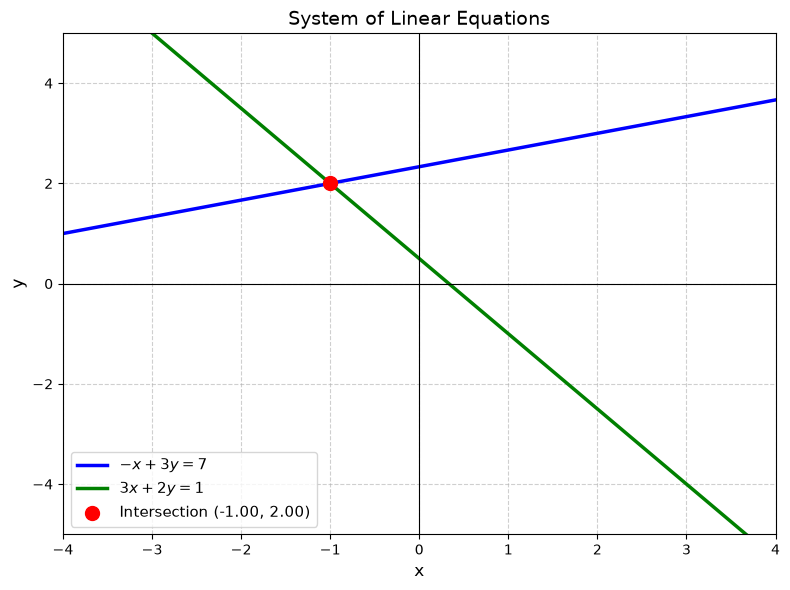

In [104]:
# Generate x values
x = np.linspace(-4, 4, 400)

# Equation 1: -x + 3y = 7
y1 = (7 + x) / 3

# Equation 2: 3x + 2y = 1
y2 = (1 - 3 * x) / 2

# Plot
plt.figure(figsize=(8, 6))

plt.plot(x, y1, label=r'$-x + 3y = 7$', linewidth=2.5, color='blue')
plt.plot(x, y2, label=r'$3x + 2y = 1$', linewidth=2.5, color='green')

# Mark intersection
plt.scatter(
    intersection[0],
    intersection[1],
    color='red',
    s=100,
    zorder=5,
    label=f'Intersection ({intersection[0]:.2f}, {intersection[1]:.2f})'
)

# Axes and styling
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(True, linestyle='--', alpha=0.6)

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('System of Linear Equations', fontsize=14)

plt.legend(fontsize=11)

plt.xlim(-4, 4)
plt.ylim(-5, 5)

plt.tight_layout()
plt.show()

Notice how the lines intersect at $(x_1,x_2) = (-1, 2)$, the solution to the system of equations.

<a name='3'></a>
## 3 - System of Linear Equations with No Solutions

Given another system of linear equations:

$$
\begin{cases} 
-x_1+3x_2=7, \\ 3x_1-9x_2=1, \end{cases}\tag{2}
$$

Let's find the determinant of the corresponding matrix.

In [105]:
A_2 = np.array([
        [-1, 3],
        [3, -9]
    ], dtype=np.dtype(float))

b_2 = np.array([7, 1], dtype=np.dtype(float))

d_2 = np.linalg.det(A_2)

print(f"Determinant of matrix A_2: {d_2:.2f}")

Determinant of matrix A_2: -0.00


In [106]:
if np.isclose(np.linalg.det(A_2), 0):
    print("Singular matrix")
else:
    x_2 = np.linalg.solve(A_2, b_2)
    print(x_2)

Singular matrix


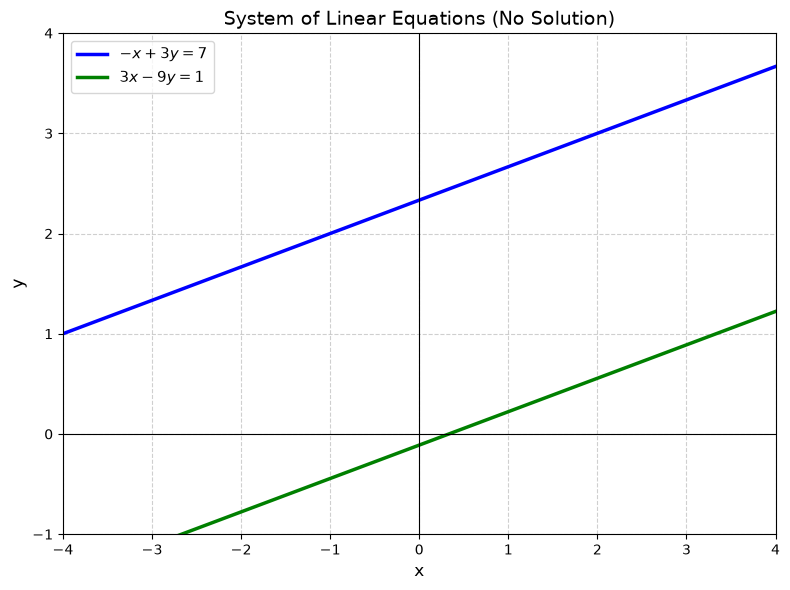

In [107]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-4, 4, 400)

# Equation 1: -x + 3y = 7
y1 = (7 + x) / 3

# Equation 2: 3x - 9y = 1
y2 = (3 * x - 1) / 9

plt.figure(figsize=(8, 6))

plt.plot(x, y1, label=r'$-x + 3y = 7$', linewidth=2.5, color='blue')
plt.plot(x, y2, label=r'$3x - 9y = 1$', linewidth=2.5, color='green')

# Axes and styling
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('System of Linear Equations (No Solution)', fontsize=14)

plt.legend(fontsize=11)

plt.xlim(-4, 4)
plt.ylim(-1, 4)

plt.tight_layout()
plt.show()

Since the determinant is zero , the matix is Singular and Linearly dependent Matrix.

<a name='4'></a>
## 4 - System of Linear Equations with an Infinite Number of Solutions

By changing the free coefficients of the system $(2)$, you can bring it to consistency:

$$
\begin{cases} 
-x_1+3x_2=7, \\ 3x_1-9x_2=-21, \end{cases}\tag{3}
$$

In [108]:
A_3 = np.array([
    [-1, 3],
    [3,-9]
])
b_3 = np.array([
    7,-21
])

d_3 = 0.0 if np.isclose(np.linalg.det(A_3),0) else np.linalg.det(A_3)

print(d_3)

0.0


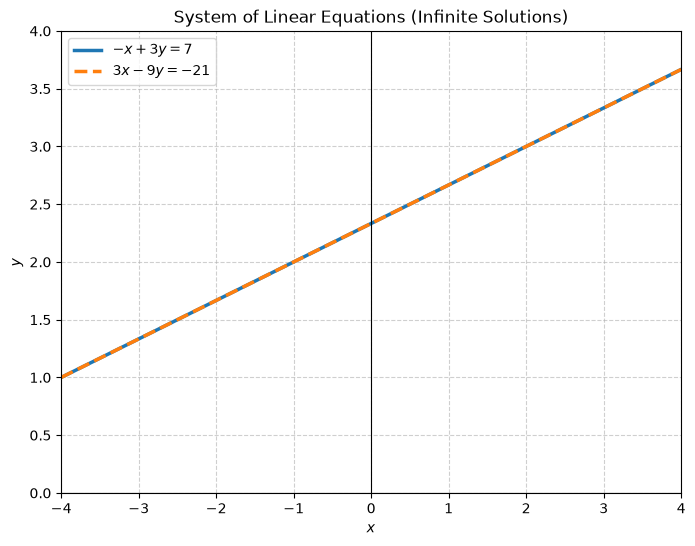

In [109]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-4, 4, 400)

# Equation 1: -x + 3y = 7
y1 = (7 + x) / 3

# Equation 2: 3x - 9y = -21
y2 = (3 * x + 21) / 9

plt.figure(figsize=(8, 6))

plt.plot(x, y1, label=r'$-x + 3y = 7$', linewidth=2.5)
plt.plot(x, y2, '--', label=r'$3x - 9y = -21$', linewidth=2.5)

# Axes
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('System of Linear Equations (Infinite Solutions)')

plt.xlim(-4, 4)
plt.ylim(0, 4)
plt.legend()

plt.show()